# Naive Responsiveness Count Exploration

Scratch notebook for `plot_naive_responsiveness_counts.py`. It rebuilds the same task familiar, expert familiar, and expert novel tables used by the export script, then exposes count distributions, NO/O scatterplots colored by naive responsive-image count, transition-plane dNO/dO scatterplots colored by naive responsive-image count, dNO and dO versus responsive-image count colored by rotated sector with sector mean traces, rotated-sector composition percentages by count, and threshold sensitivity.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

import context_contrasting.data_analysis.plot_naive_responsiveness_counts as nrc
import context_contrasting.data_analysis.transitions_helpers as th

DATA_DIR = Path.cwd()
if DATA_DIR.name != "data_analysis":
    DATA_DIR = Path("context_contrasting/data_analysis")

OUTPUT_DIR = DATA_DIR / "naive_responsiveness_count_scatter"
RESPONSE_THRESHOLD = nrc.DEFAULT_RESPONSE_THRESHOLD
SECTOR_THRESHOLD = 0.3
POINT_SIZE = 30.0
THRESHOLD_OUTPUT_DIR = OUTPUT_DIR / nrc._threshold_folder(RESPONSE_THRESHOLD)
NOTEBOOK_PREVIEW_DIR = THRESHOLD_OUTPUT_DIR / "notebook_previews"
NOTEBOOK_PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR, OUTPUT_DIR, THRESHOLD_OUTPUT_DIR, RESPONSE_THRESHOLD, SECTOR_THRESHOLD

(PosixPath('context_contrasting/data_analysis'),
 PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter'),
 PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3'),
 0.3,
 0.3)

In [2]:
act_table = th.load_transition_table(DATA_DIR / "transitions_act.csv")
post_table = th.load_transition_table(DATA_DIR / "transitions_post.csv")

summary_specs = {
    "task_familiar": {
        "transition_table": act_table,
        "image_group": "all",
        "target_stage": "Task",
    },
    "expert_familiar": {
        "transition_table": post_table,
        "image_group": "familiar",
        "target_stage": "Post",
    },
    "expert_novel": {
        "transition_table": post_table,
        "image_group": "novel",
        "target_stage": "Post",
    },
}

def build_summaries(response_threshold: float = RESPONSE_THRESHOLD) -> dict[str, pd.DataFrame]:
    summaries = {}
    for name, spec in summary_specs.items():
        frame = nrc.build_colored_summary(
            spec["transition_table"],
            image_group=spec["image_group"],
            target_stage=spec["target_stage"],
            response_threshold=response_threshold,
            sector_threshold=SECTOR_THRESHOLD,
        )
        frame.insert(0, "summary_name", name)
        summaries[name] = frame
    return summaries

summaries = build_summaries()
merged = pd.concat(summaries.values(), ignore_index=True)

print({name: frame.shape for name, frame in summaries.items()})
merged.head()

{'task_familiar': (110, 23), 'expert_familiar': (166, 25), 'expert_novel': (166, 25)}


,summary_name,neuron_idx,NO_Pre,NO_Target,O_Pre,O_Target,dNO,dO,dNorm,log_dNorm,...,naive_max_NO,naive_responsive_all_count,naive_total_all_count,response_threshold,summary_image_group,target_stage,naive_responsive_familiar_count,naive_responsive_novel_count,naive_total_familiar_count,naive_total_novel_count
0,task_familiar,1,0.418448,-0.205590,0.389519,1.207470,-0.624038,0.817951,1.028818,0.028412,...,1.059138,2.0,4.0,0.3,all,Task,NaN,NaN,NaN,NaN
1,task_familiar,2,0.799413,-0.163604,0.052964,0.392391,-0.963017,0.339427,1.021084,0.020866,...,1.639101,2.0,4.0,0.3,all,Task,NaN,NaN,NaN,NaN
2,task_familiar,3,0.528374,-0.208662,0.155591,-0.378016,-0.737036,-0.533607,0.909922,-0.094395,...,0.898214,2.0,4.0,0.3,all,Task,NaN,NaN,NaN,NaN
3,task_familiar,4,2.479678,2.023693,0.185779,0.001424,-0.455984,-0.184355,0.491842,-0.709596,...,3.316497,4.0,4.0,0.3,all,Task,NaN,NaN,NaN,NaN
4,task_familiar,5,0.571079,0.510248,-0.010418,-0.040830,-0.060831,-0.030412,0.068010,-2.688090,...,0.816547,4.0,4.0,0.3,all,Task,NaN,NaN,NaN,NaN


In [3]:
def naive_image_table(transition_table: pd.DataFrame, *, response_threshold: float) -> pd.DataFrame:
    naive = transition_table.loc[transition_table["stage"].astype(str) == "Pre"].copy()
    naive = naive[["neuron_idx", "image_group", "image_idx_original", "image_idx_within_group", "NO", "O"]]
    naive = naive.drop_duplicates()
    naive["naive_responsive"] = naive["NO"] > response_threshold
    return naive

act_naive_images = naive_image_table(act_table, response_threshold=RESPONSE_THRESHOLD)
post_naive_images = naive_image_table(post_table, response_threshold=RESPONSE_THRESHOLD)

print("Act naive image rows", act_naive_images.shape)
display(act_naive_images.groupby(["image_group", "image_idx_original"], as_index=False).agg(
    neurons=("neuron_idx", "nunique"),
    responsive_fraction=("naive_responsive", "mean"),
    mean_NO=("NO", "mean"),
    median_NO=("NO", "median"),
))

print("Post naive image rows", post_naive_images.shape)
display(post_naive_images.groupby(["image_group", "image_idx_original"], as_index=False).agg(
    neurons=("neuron_idx", "nunique"),
    responsive_fraction=("naive_responsive", "mean"),
    mean_NO=("NO", "mean"),
    median_NO=("NO", "median"),
))

Act naive image rows (440, 7)


,image_group,image_idx_original,neurons,responsive_fraction,mean_NO,median_NO
0,all,1,110,0.390909,0.360080,0.188674
1,all,2,110,0.418182,0.632934,0.197677
2,all,3,110,0.445455,0.473584,0.246159
3,all,4,110,0.409091,0.428718,0.195993


Post naive image rows (996, 7)


,image_group,image_idx_original,neurons,responsive_fraction,mean_NO,median_NO
0,familiar,1,166,0.379518,0.368240,0.178213
1,familiar,2,166,0.409639,0.621833,0.176269
2,familiar,4,166,0.427711,0.403662,0.237314
3,familiar,5,166,0.373494,0.419205,0.171193
4,novel,3,166,0.337349,0.411705,0.104448
5,novel,6,166,0.283133,0.235103,0.124810


In [4]:
count_distribution = (
    merged.groupby(["summary_name", "naive_responsive_image_count"], as_index=False)
    .agg(neuron_count=("neuron_idx", "size"))
    .sort_values(["summary_name", "naive_responsive_image_count"])
)
display(count_distribution)

display(count_distribution.pivot(
    index="naive_responsive_image_count",
    columns="summary_name",
    values="neuron_count",
).fillna(0).astype(int))

sector_by_count = (
    merged.groupby(["summary_name", "RotatedSector", "naive_responsive_image_count"], observed=True, as_index=False)
    .agg(neuron_count=("neuron_idx", "size"), mean_dNO=("dNO", "mean"), mean_dO=("dO", "mean"))
    .sort_values(["summary_name", "RotatedSector", "naive_responsive_image_count"])
)
display(sector_by_count.head(20))

,summary_name,naive_responsive_image_count,neuron_count
0,expert_familiar,0,43
1,expert_familiar,1,35
2,expert_familiar,2,24
3,expert_familiar,3,15
4,expert_familiar,4,17
5,expert_familiar,5,21
6,expert_familiar,6,11
7,expert_novel,0,43
8,expert_novel,1,35
9,expert_novel,2,24


summary_name,expert_familiar,expert_novel,task_familiar
naive_responsive_image_count,,,
0,43,43,41
1,35,35,16
2,24,24,17
3,15,15,11
4,17,17,25
5,21,21,0
6,11,11,0


,summary_name,RotatedSector,naive_responsive_image_count,neuron_count,mean_dNO,mean_dO
0,expert_familiar,+NO axis,0,3,0.321777,0.146604
1,expert_familiar,+NO axis,1,5,0.683522,0.192810
2,expert_familiar,+NO axis,2,1,0.255126,0.219409
3,expert_familiar,+NO axis,3,1,0.578138,0.046967
4,expert_familiar,+NO axis,4,2,0.519495,-0.044219
5,expert_familiar,+NO axis,5,2,0.557148,-0.090074
6,expert_familiar,+O axis,0,12,0.068995,0.477991
7,expert_familiar,+O axis,1,6,-0.001926,0.341219
8,expert_familiar,+O axis,2,2,-0.656665,0.836057
9,expert_familiar,+O axis,3,1,-0.461973,0.656035


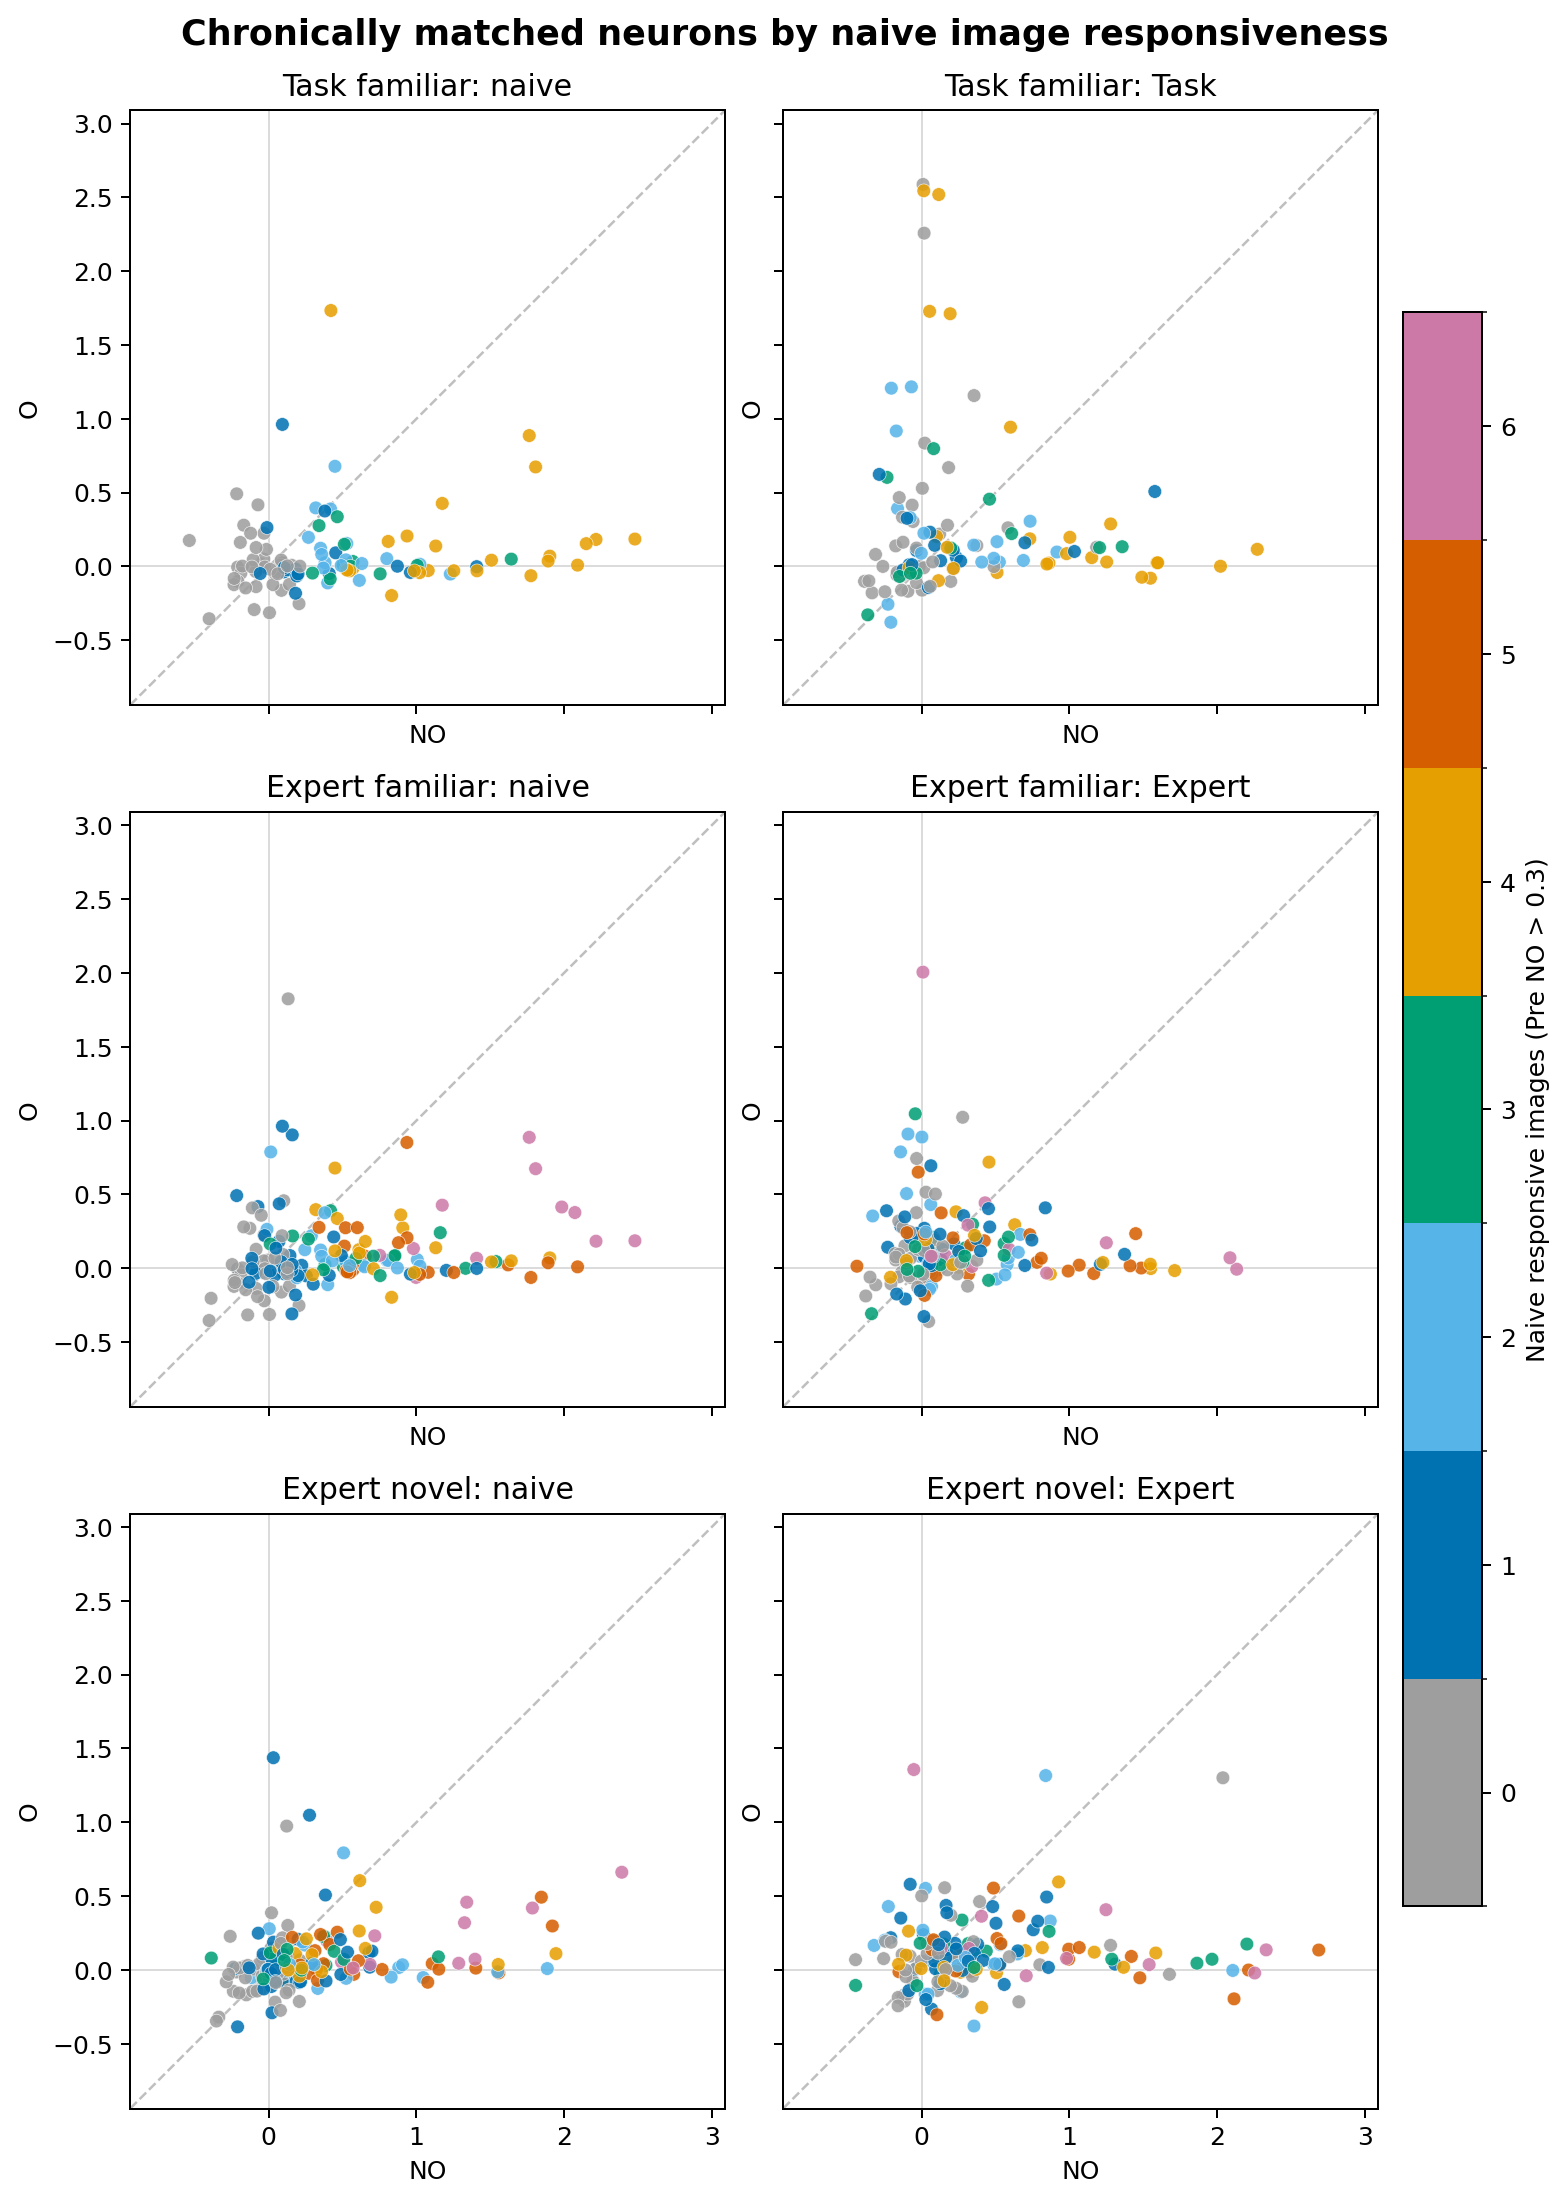

In [5]:
response_lims = th.compute_response_limits(*summaries.values())

fig_combined = nrc.plot_combined_responsiveness_scatter(
    summaries,
    response_lims=response_lims,
    response_threshold=RESPONSE_THRESHOLD,
    point_size=POINT_SIZE,
)
combined_preview_path = NOTEBOOK_PREVIEW_DIR / f"combined_scatter_{nrc._threshold_tag(RESPONSE_THRESHOLD)}.png"
fig_combined.savefig(combined_preview_path, dpi=180, bbox_inches="tight")
display(Image(filename=str(combined_preview_path)))

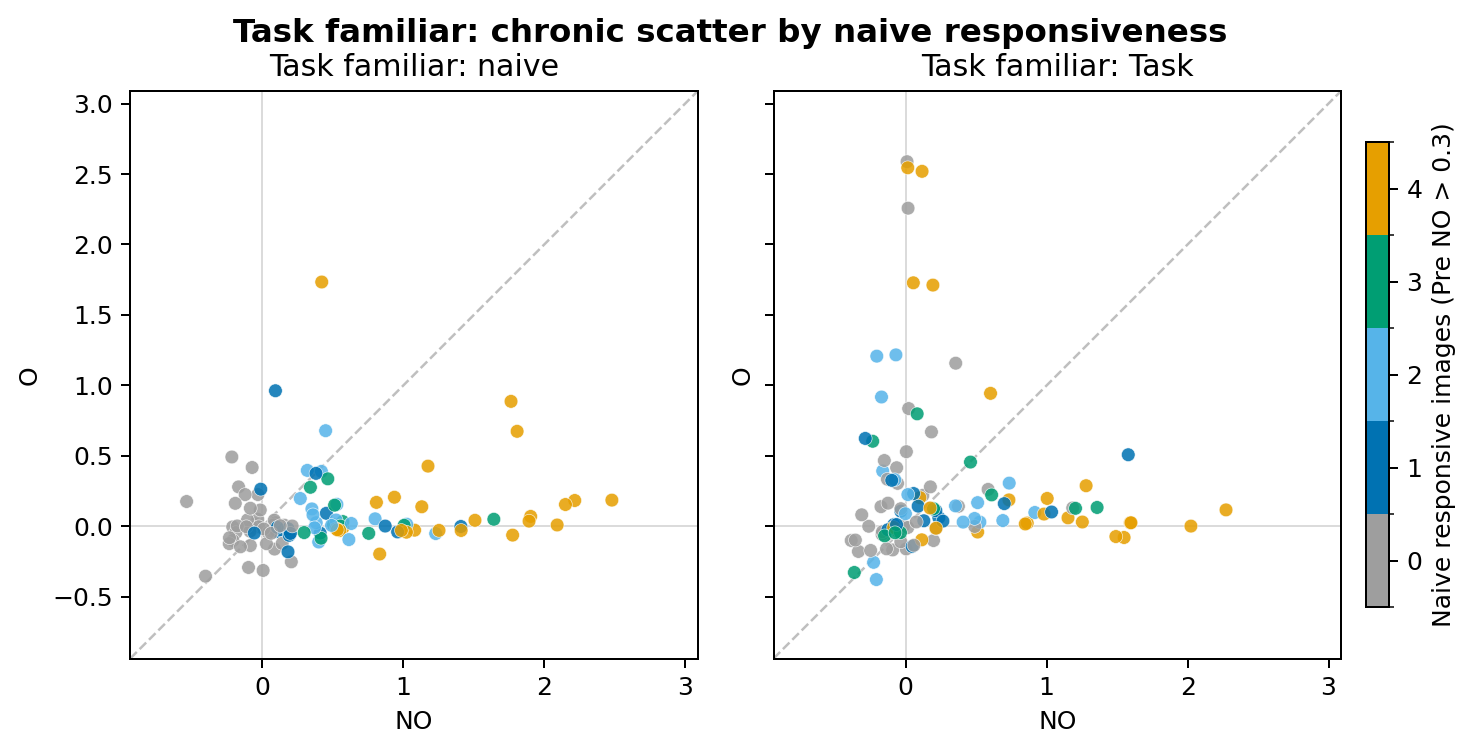

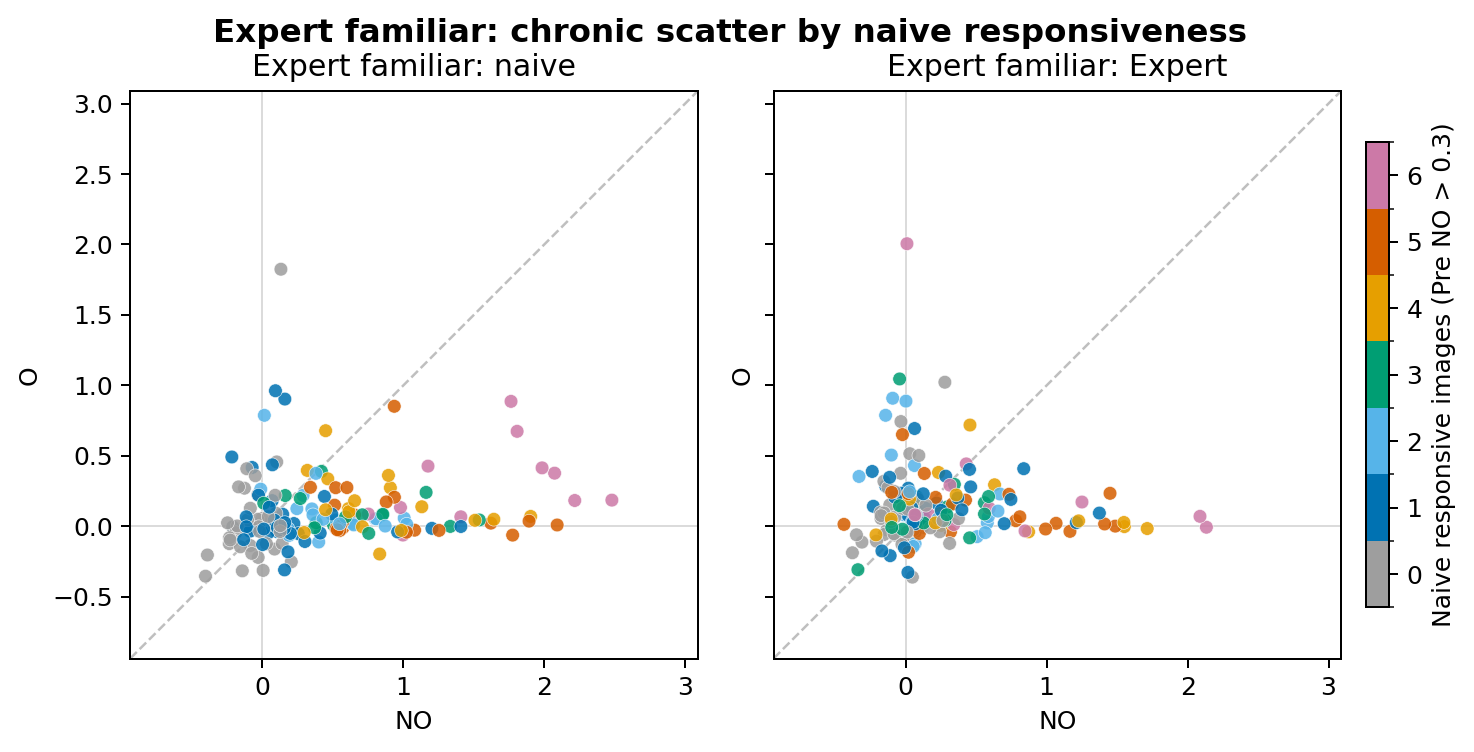

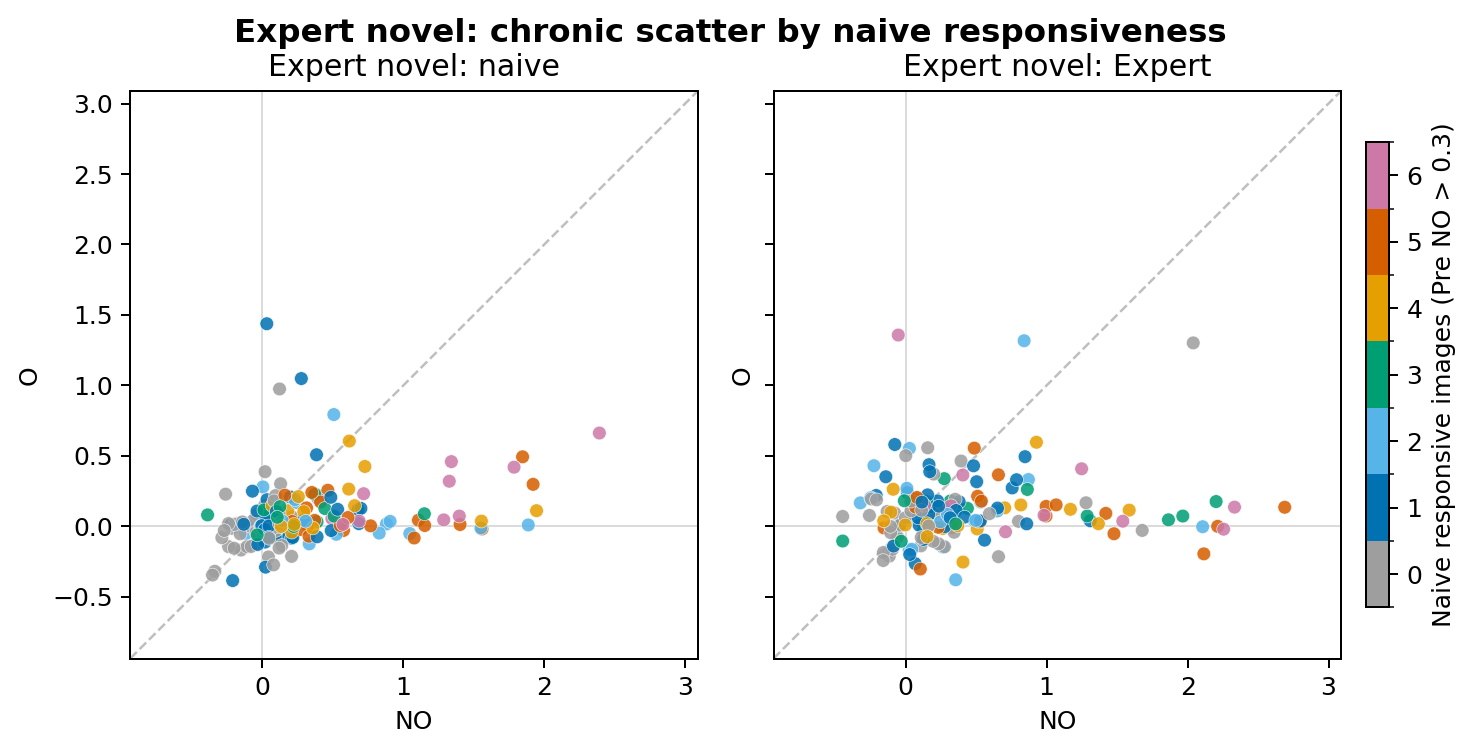

{'task_familiar': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/task_familiar_scatter_by_naive_responsive_count_gt_0_3.png'),
 'expert_familiar': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/expert_familiar_scatter_by_naive_responsive_count_gt_0_3.png'),
 'expert_novel': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/expert_novel_scatter_by_naive_responsive_count_gt_0_3.png')}

In [6]:
response_scatter_preview_paths = {}
for label, frame in summaries.items():
    fig = nrc.plot_single_responsiveness_scatter(
        frame,
        label=label,
        response_lims=response_lims,
        response_threshold=RESPONSE_THRESHOLD,
        point_size=POINT_SIZE,
    )
    path = NOTEBOOK_PREVIEW_DIR / f"{label}_scatter_by_naive_responsive_count_{nrc._threshold_tag(RESPONSE_THRESHOLD)}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    response_scatter_preview_paths[label] = path
    display(Image(filename=str(path)))

response_scatter_preview_paths

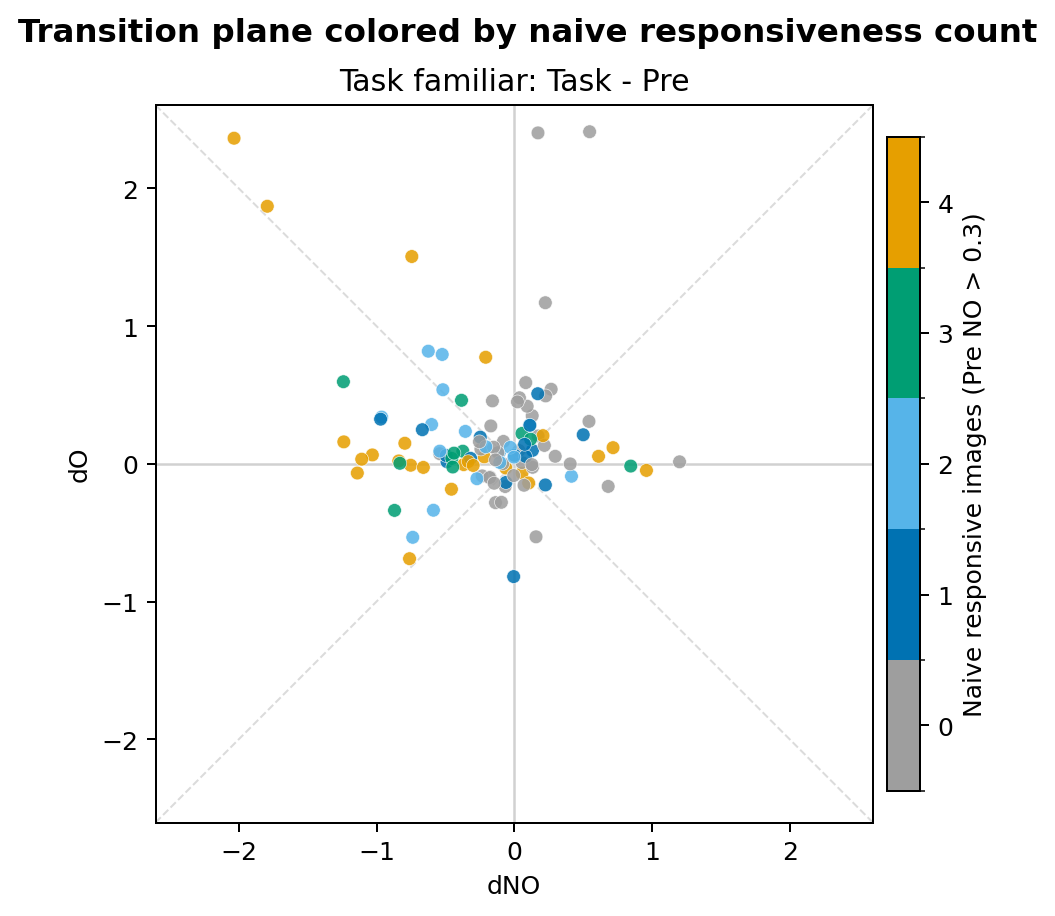

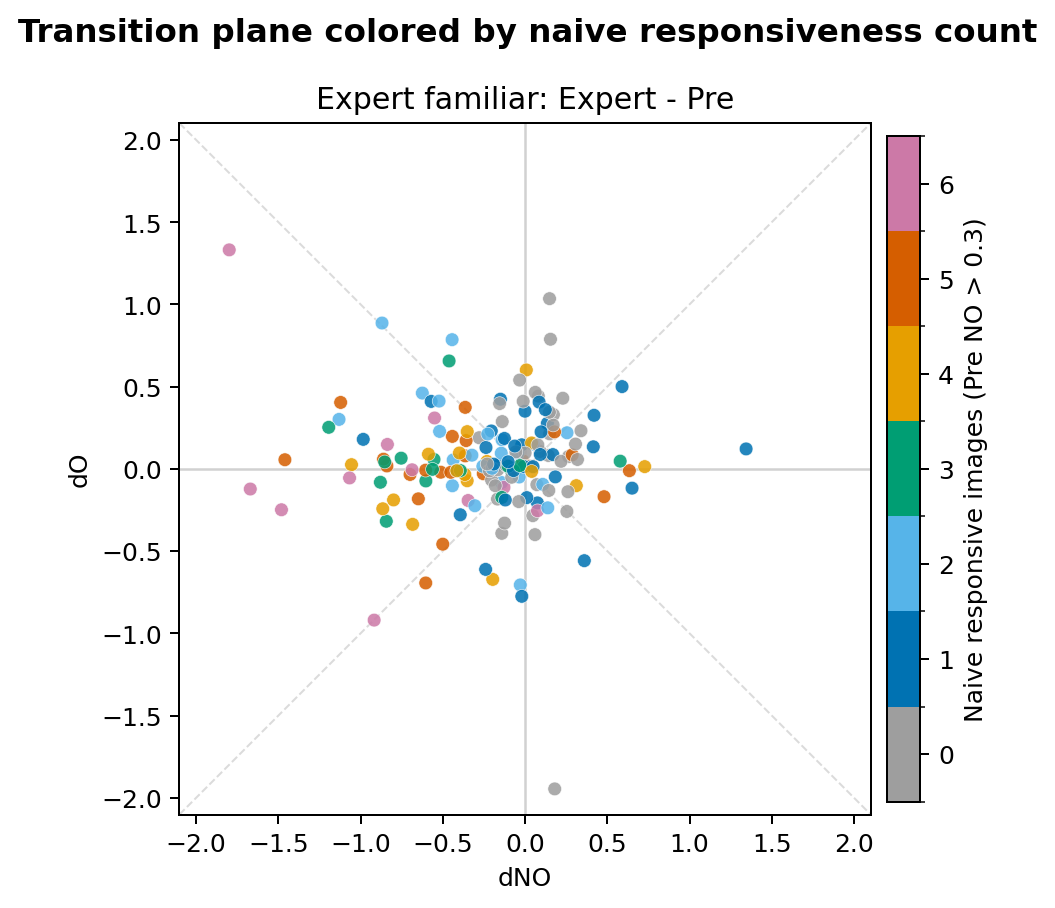

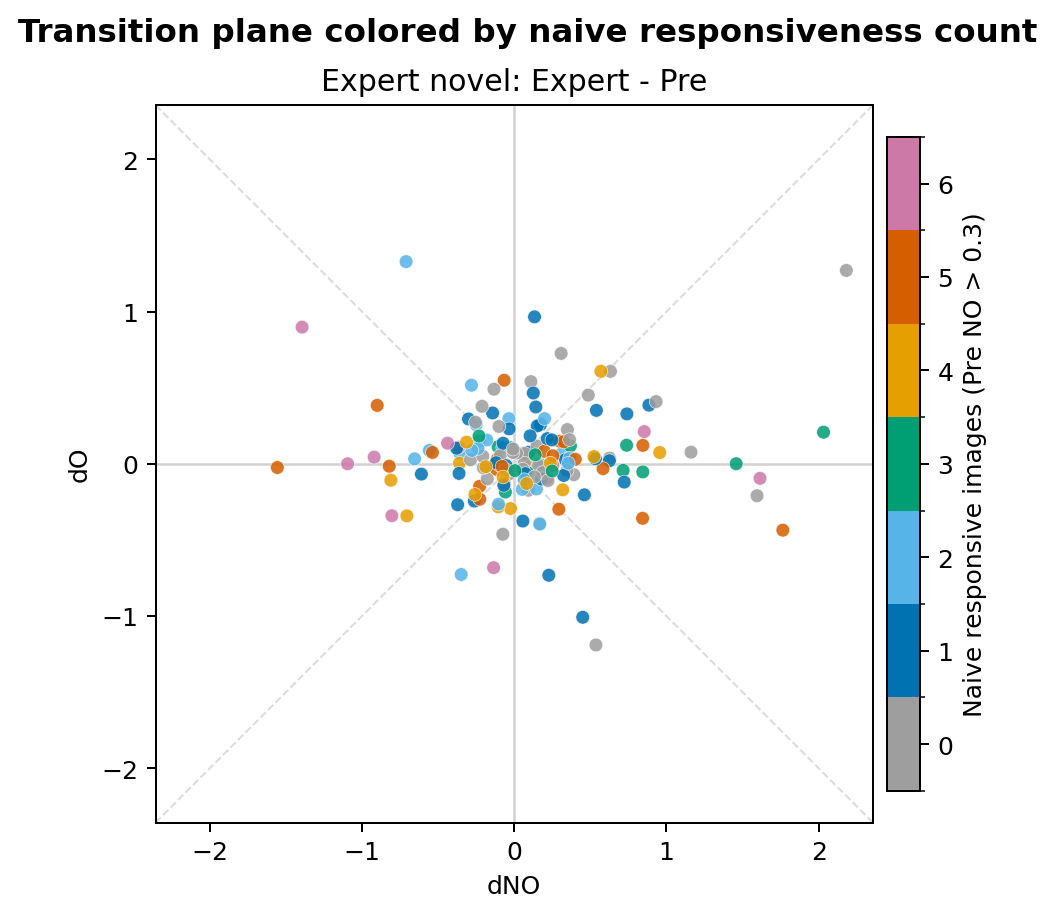

{'task_familiar': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/task_familiar_delta_by_naive_responsive_count_gt_0_3.png'),
 'expert_familiar': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/expert_familiar_delta_by_naive_responsive_count_gt_0_3.png'),
 'expert_novel': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/expert_novel_delta_by_naive_responsive_count_gt_0_3.png')}

In [7]:
delta_count_figures = {}
delta_count_preview_paths = {}
for label, frame in summaries.items():
    fig = nrc.plot_delta_by_responsive_count(
        frame,
        label=label,
        response_threshold=RESPONSE_THRESHOLD,
        point_size=POINT_SIZE,
    )
    path = NOTEBOOK_PREVIEW_DIR / f"{label}_delta_by_naive_responsive_count_{nrc._threshold_tag(RESPONSE_THRESHOLD)}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    delta_count_figures[label] = fig
    delta_count_preview_paths[label] = path
    display(Image(filename=str(path)))

delta_count_preview_paths

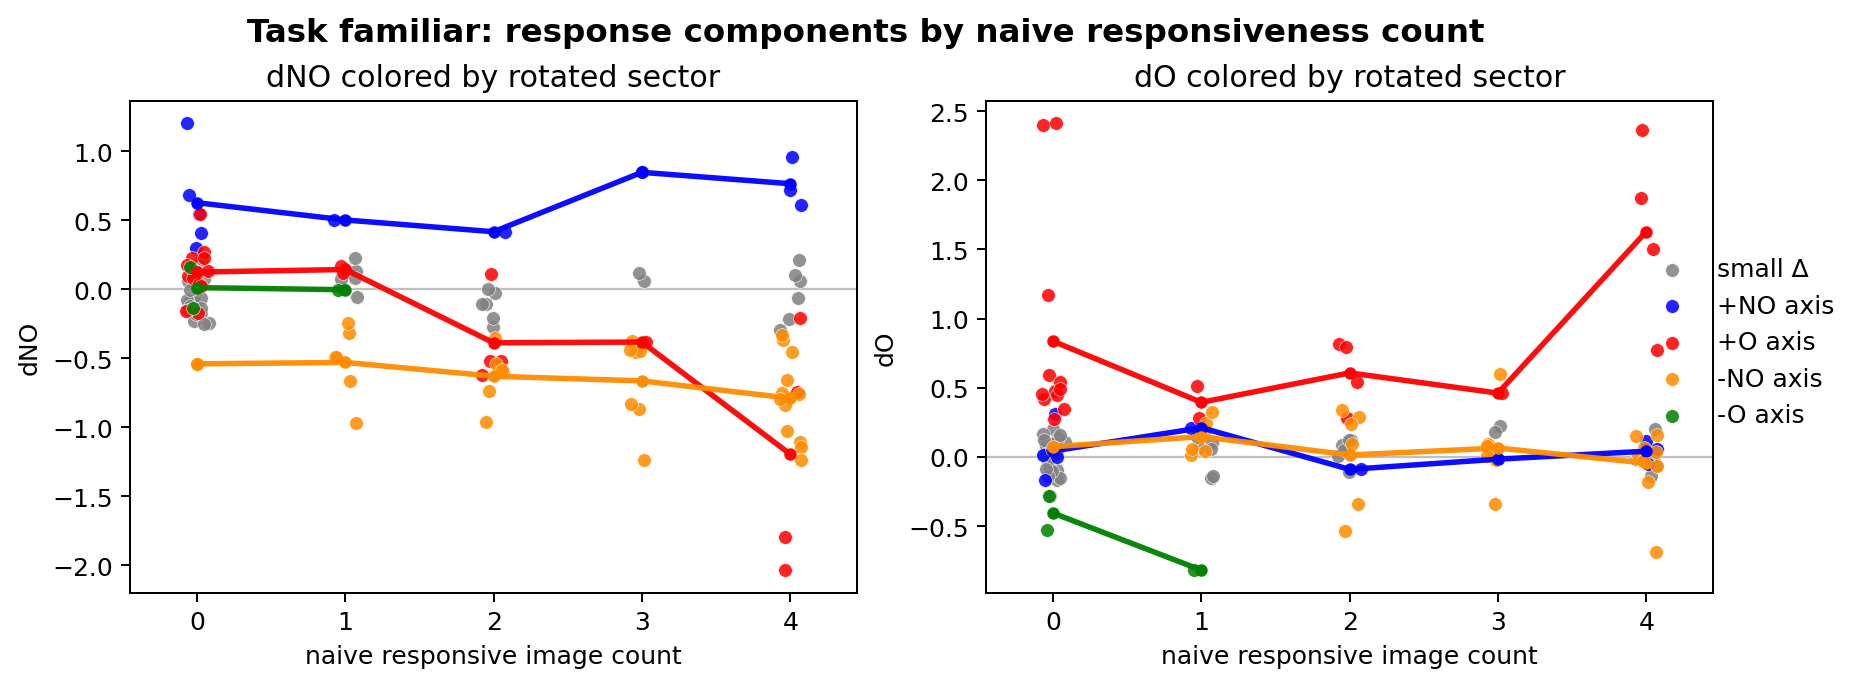

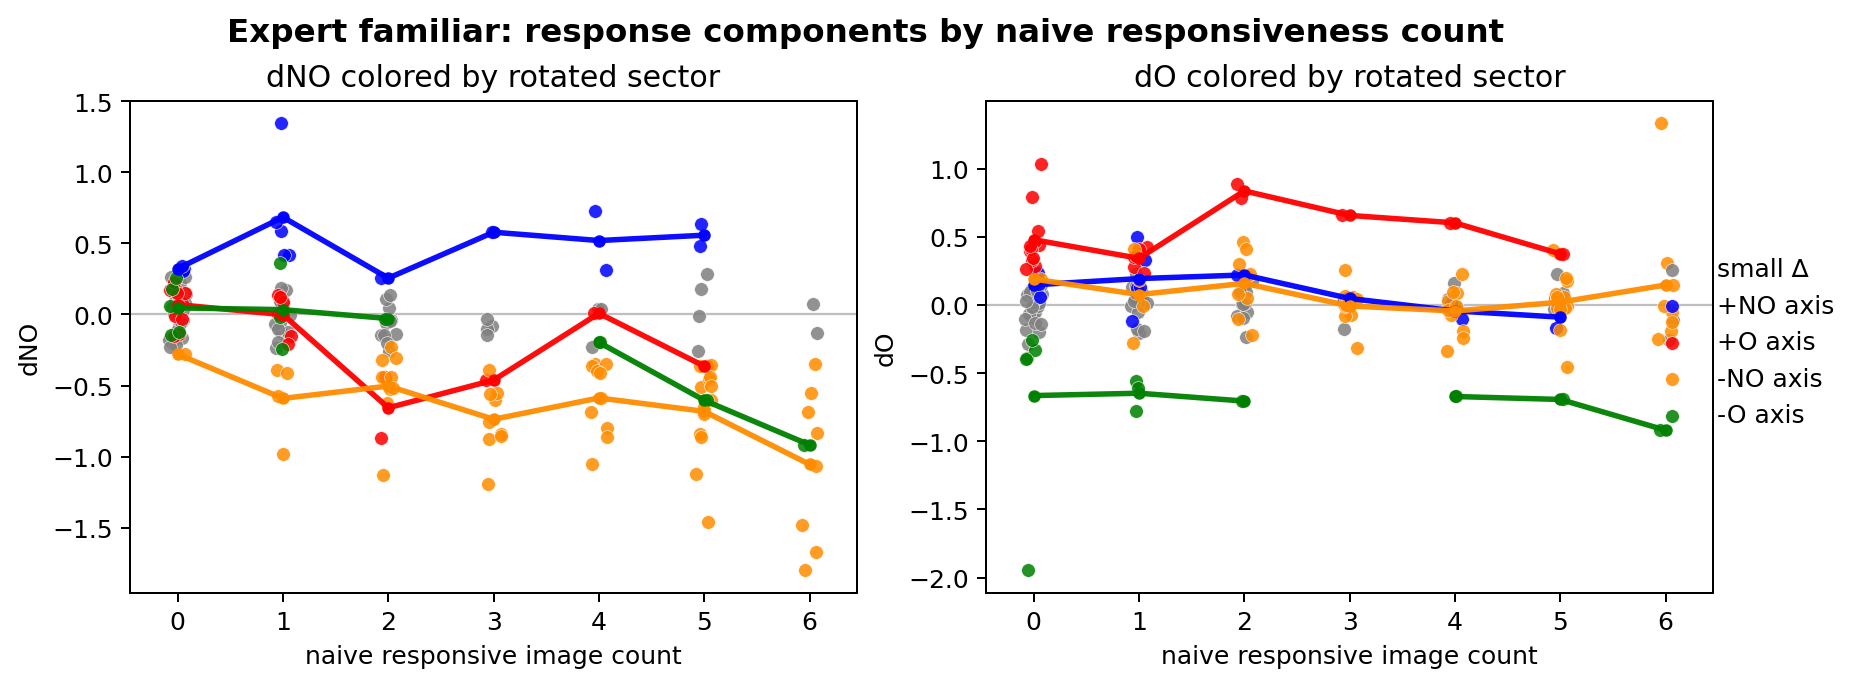

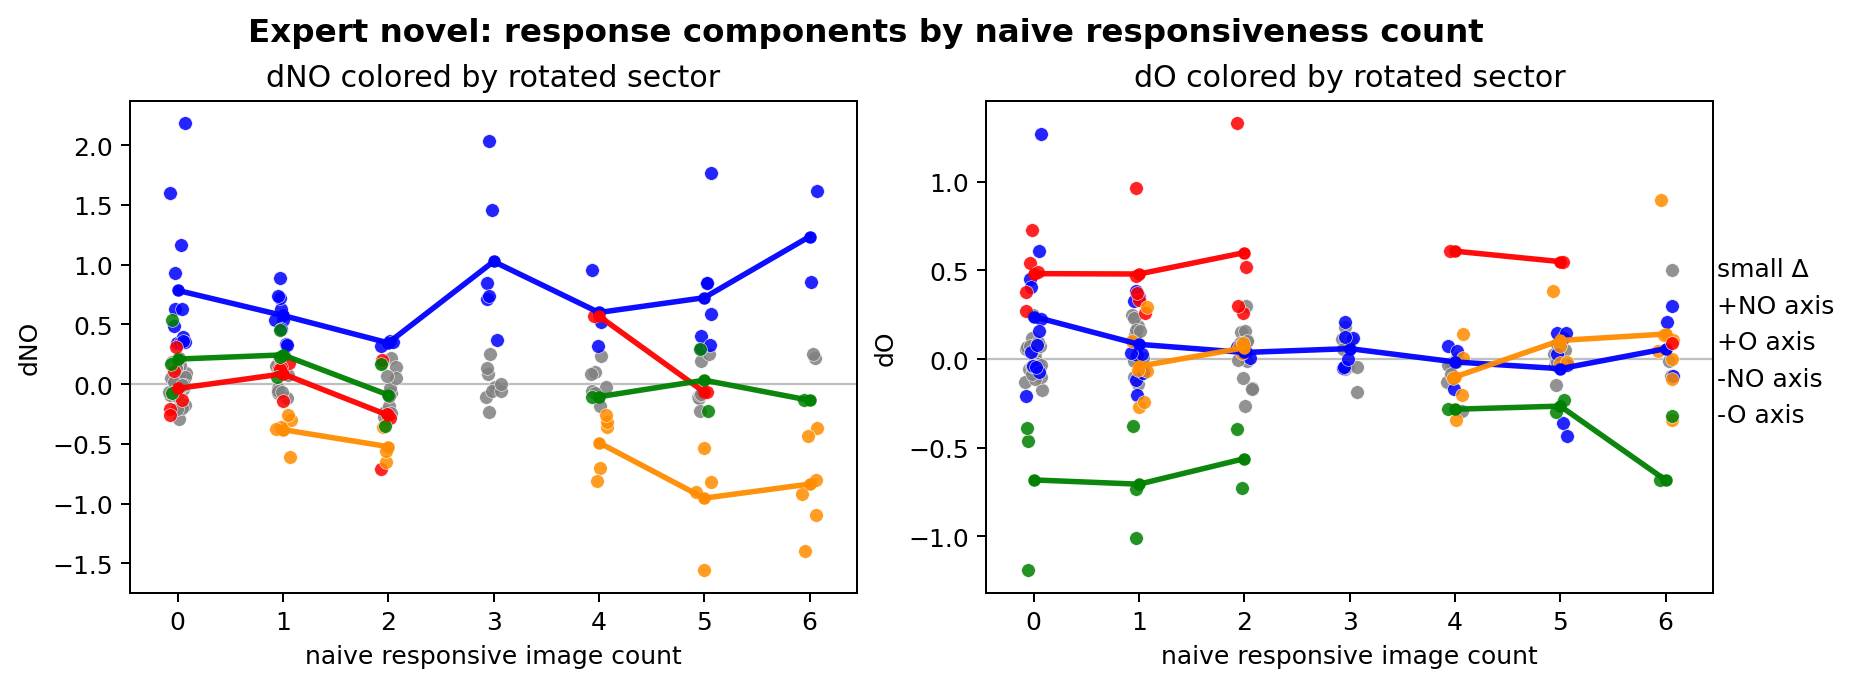

{'task_familiar': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/task_familiar_delta_by_rotated_sector_count_gt_0_3.png'),
 'expert_familiar': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/expert_familiar_delta_by_rotated_sector_count_gt_0_3.png'),
 'expert_novel': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/expert_novel_delta_by_rotated_sector_count_gt_0_3.png')}

In [8]:
delta_sector_figures = {}
delta_sector_preview_paths = {}
for label, frame in summaries.items():
    fig = nrc.plot_delta_by_responsive_count_sectors(
        frame,
        label=label,
        point_size=POINT_SIZE,
    )
    path = NOTEBOOK_PREVIEW_DIR / f"{label}_delta_by_rotated_sector_count_{nrc._threshold_tag(RESPONSE_THRESHOLD)}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    delta_sector_figures[label] = fig
    delta_sector_preview_paths[label] = path
    display(Image(filename=str(path)))

delta_sector_preview_paths

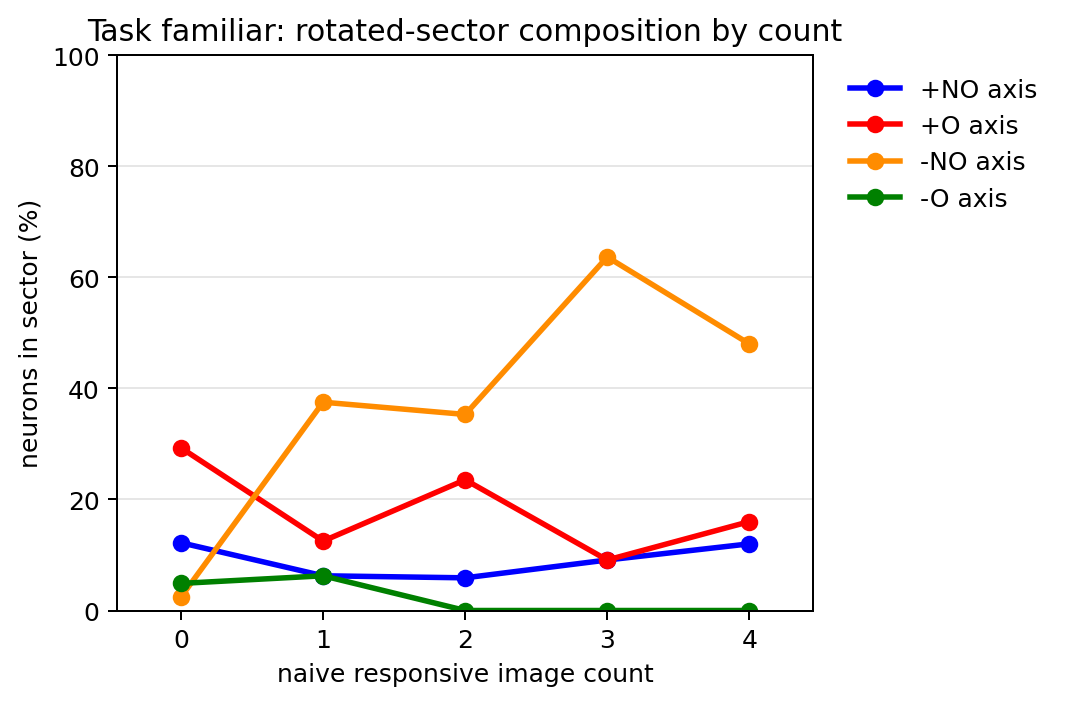

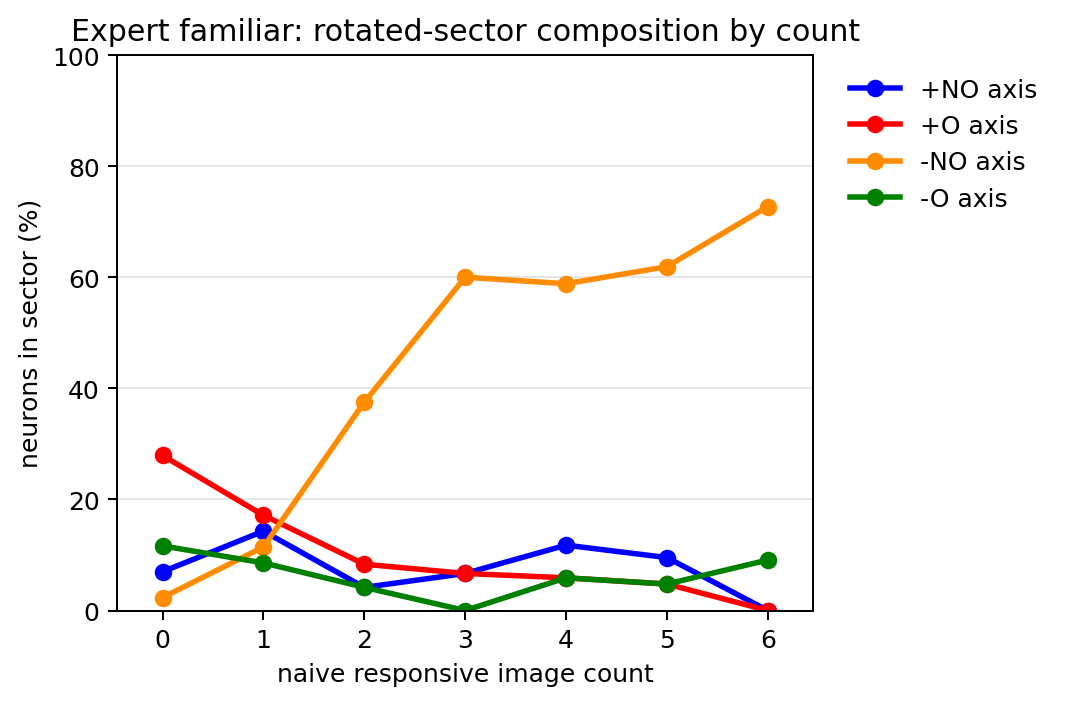

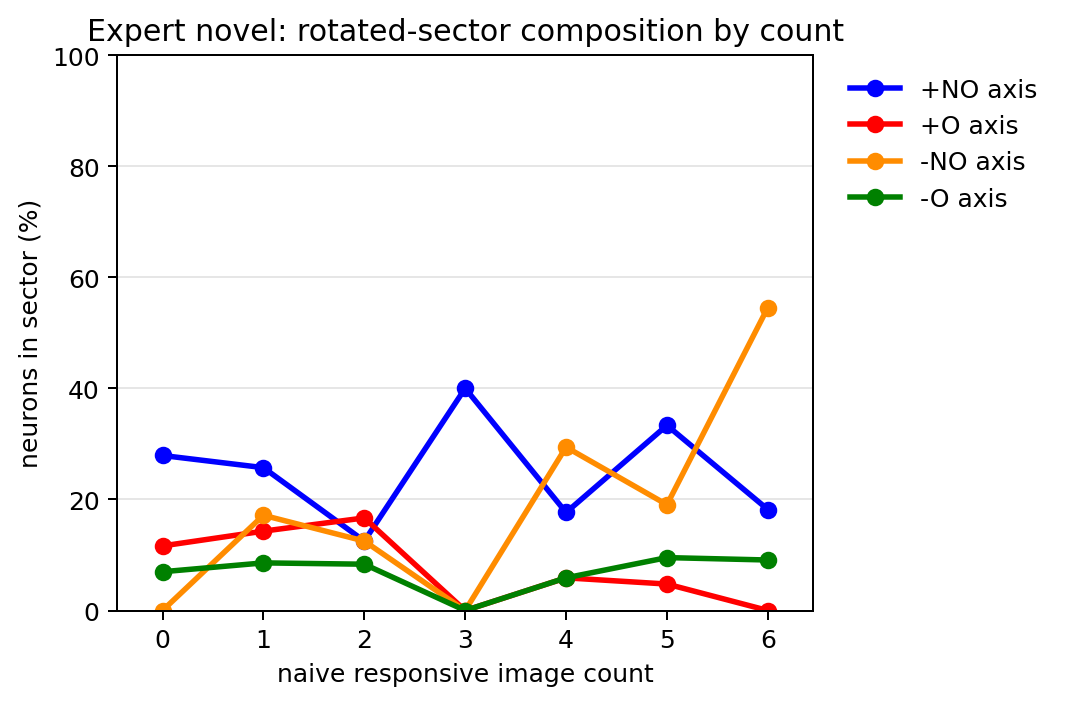

{'task_familiar': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/task_familiar_sector_percentage_by_naive_responsive_count_gt_0_3.png'),
 'expert_familiar': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/expert_familiar_sector_percentage_by_naive_responsive_count_gt_0_3.png'),
 'expert_novel': PosixPath('context_contrasting/data_analysis/naive_responsiveness_count_scatter/0.3/notebook_previews/expert_novel_sector_percentage_by_naive_responsive_count_gt_0_3.png')}

In [9]:
sector_percentage_figures = {}
sector_percentage_preview_paths = {}
for label, frame in summaries.items():
    fig = nrc.plot_sector_percentage_by_responsive_count(
        frame,
        label=label,
    )
    path = NOTEBOOK_PREVIEW_DIR / f"{label}_sector_percentage_by_naive_responsive_count_{nrc._threshold_tag(RESPONSE_THRESHOLD)}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    sector_percentage_figures[label] = fig
    sector_percentage_preview_paths[label] = path
    display(Image(filename=str(path)))

sector_percentage_preview_paths

,summary_name,naive_responsive_image_count,neuron_count,response_threshold
0,expert_familiar,0,26,0.2
1,expert_familiar,1,31,0.2
2,expert_familiar,2,27,0.2
3,expert_familiar,3,24,0.2
4,expert_familiar,4,14,0.2
...,...,...,...,...
107,task_familiar,0,71,1.0
108,task_familiar,1,19,1.0
109,task_familiar,2,13,1.0
110,task_familiar,3,5,1.0


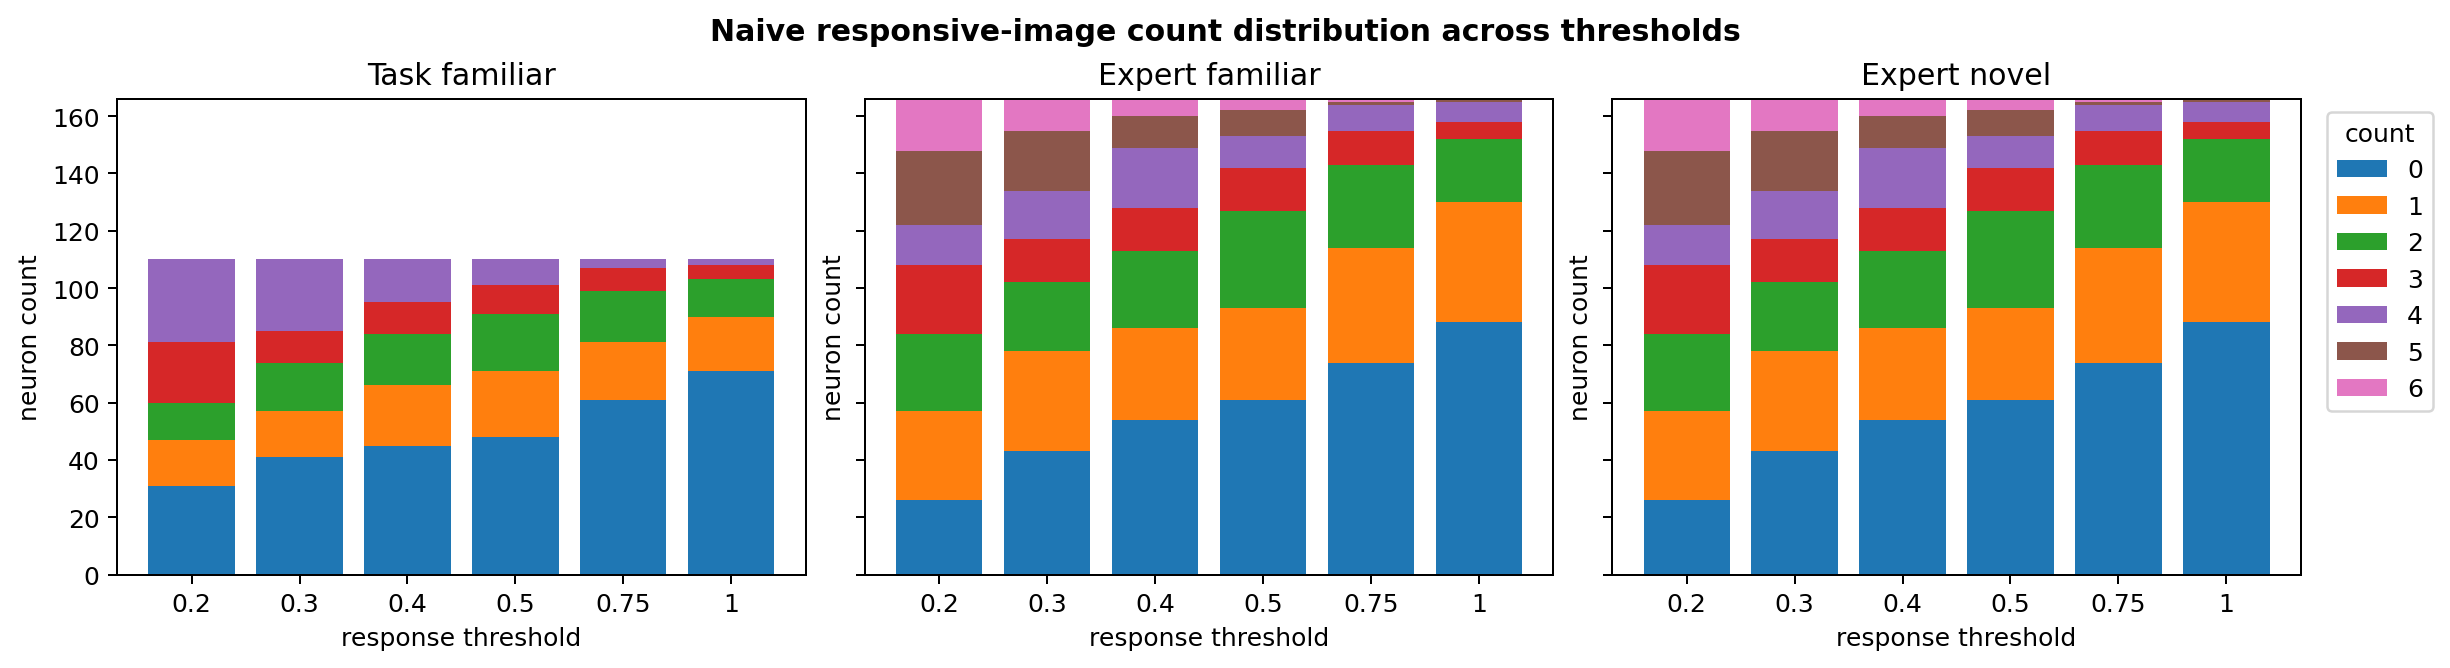

In [10]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.75, 1.0]
sweep_rows = []
for threshold in thresholds:
    sweep_summaries = build_summaries(response_threshold=threshold)
    sweep_merged = pd.concat(sweep_summaries.values(), ignore_index=True)
    dist = (
        sweep_merged.groupby(["summary_name", "naive_responsive_image_count"], as_index=False)
        .agg(neuron_count=("neuron_idx", "size"))
    )
    dist["response_threshold"] = threshold
    sweep_rows.append(dist)

threshold_sweep = pd.concat(sweep_rows, ignore_index=True)
display(threshold_sweep)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6), sharey=True, constrained_layout=True)
for ax, summary_name in zip(axes, ["task_familiar", "expert_familiar", "expert_novel"]):
    table = threshold_sweep.loc[threshold_sweep["summary_name"] == summary_name]
    pivot = table.pivot(
        index="response_threshold",
        columns="naive_responsive_image_count",
        values="neuron_count",
    ).fillna(0).sort_index()
    bottom = np.zeros(len(pivot), dtype=float)
    x = np.arange(len(pivot))
    for count in pivot.columns:
        values = pivot[count].to_numpy(dtype=float)
        ax.bar(x, values, bottom=bottom, label=str(count))
        bottom += values
    ax.set_title(nrc.DISPLAY_LABELS[summary_name])
    ax.set_xticks(x)
    ax.set_xticklabels([f"{thr:g}" for thr in pivot.index])
    ax.set_xlabel("response threshold")
    ax.set_ylabel("neuron count")
axes[-1].legend(title="count", bbox_to_anchor=(1.02, 1.0), loc="upper left")
fig.suptitle("Naive responsive-image count distribution across thresholds", fontweight="bold")
threshold_sweep_preview_path = NOTEBOOK_PREVIEW_DIR / "threshold_sweep_distribution.png"
fig.savefig(threshold_sweep_preview_path, dpi=180, bbox_inches="tight")
display(Image(filename=str(threshold_sweep_preview_path)))